<a href="https://colab.research.google.com/github/Ajwad07/ML_projects_/blob/main/CNN%2BTransformer_Image_Captioning_Notebook_python_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# START HERE

In [1]:
# ============================================================
# 1. Mount Google Drive for saving model
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

# ============================================================
# 2. Install dependencies
# ============================================================
!pip install --quiet gradio tqdm nltk



Mounted at /content/drive


In [2]:
# ============================================================
# 3. Import libraries
# ============================================================
import os, json, torch, nltk
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm
import gradio as gr
import numpy as np

# ============================================================
# 4. Download & extract MS COCO val2017 (first 10k images)
# ============================================================
os.makedirs('coco', exist_ok=True)
if not os.path.exists('coco/val2017'):
    !wget -O coco/val2017.zip http://images.cocodataset.org/zips/val2017.zip
    !unzip -q coco/val2017.zip -d coco/
if not os.path.exists('coco/annotations'):
    !wget -O coco/annotations_trainval2017.zip http://images.cocodataset.org/annotations/annotations_trainval2017.zip
    !unzip -q coco/annotations_trainval2017.zip -d coco/




--2025-08-13 13:02:30--  http://images.cocodataset.org/zips/val2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 16.15.186.209, 52.217.141.249, 16.15.176.111, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|16.15.186.209|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 815585330 (778M) [application/zip]
Saving to: ‘coco/val2017.zip’

coco/val2017.zip    100%[===================>] 777.80M  16.5MB/s    in 49s     

2025-08-13 13:03:19 (15.9 MB/s) - ‘coco/val2017.zip’ saved [815585330/815585330]

--2025-08-13 13:03:26--  http://images.cocodataset.org/annotations/annotations_trainval2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 16.182.32.137, 52.216.92.227, 3.5.25.90, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|16.182.32.137|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 252907541 (241M) [application/zip]
Saving to: ‘coco/annotations_trainval2017.zip’

coco/

In [26]:
# ============================================================
# 5. Prepare 10k image paths and first caption per image
# ============================================================
IMG_SIZE = 224
NUM_IMAGES = 20000
with open('coco/annotations/captions_val2017.json', 'r') as f:
    caps = json.load(f)
img_id_to_caps = {}
for ann in caps['annotations']:
    img_id_to_caps.setdefault(ann['image_id'], []).append(ann['caption'])
img_files = sorted(os.listdir('coco/val2017'))[:NUM_IMAGES]
image_paths = ['coco/val2017/' + f for f in img_files]
image_ids = [int(f.split('.')[0]) for f in img_files]
captions = [img_id_to_caps.get(id, ['No caption'])[0] for id in image_ids]

# ============================================================
# 6. Tokenizer class (nltk-based, vocab_size=6000)
# ============================================================
nltk.download('punkt')
nltk.download('punkt_tab')  # Ensure punkt_tab is downloaded
class SimpleTokenizer:
    def __init__(self, captions, vocab_size=6000):
        words = []
        for cap in captions:
            words.extend(nltk.word_tokenize(cap.lower()))
        freq = Counter(words)
        self.itos = ['<pad>', '<start>', '<end>', '<unk>'] + [w for w, _ in freq.most_common(vocab_size - 4)]
        self.stoi = {w: i for i, w in enumerate(self.itos)}
    def encode(self, text, max_len=25):
        tokens = ['<start>'] + nltk.word_tokenize(text.lower()) + ['<end>']
        ids = [self.stoi.get(t, self.stoi['<unk>']) for t in tokens]
        return ids[:max_len] + [0]*(max_len - len(ids))
    def decode(self, ids):
        words = []
        for i in ids:
            if i == self.stoi['<end>']:
                break
            if i > 3:
                words.append(self.itos[i])
        return ' '.join(words)

tokenizer = SimpleTokenizer(captions)

# ============================================================
# 7. Dataset class
# ============================================================
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class CocoDataset(Dataset):
    def __init__(self, image_paths, captions, tokenizer):
        self.image_paths = image_paths
        self.captions = captions
        self.tokenizer = tokenizer
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        image = transform(image)
        cap_ids = torch.tensor(self.tokenizer.encode(self.captions[idx]))
        return image, cap_ids[:-1], cap_ids[1:]  # input, target



[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [27]:
# ============================================================
# 8. Train/Val split & Dataloader
# ============================================================
dataset = CocoDataset(image_paths, captions, tokenizer)
train_size = int(0.85 * len(dataset))
train_set, val_set = torch.utils.data.random_split(dataset, [train_size, len(dataset)-train_size])
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
val_loader = DataLoader(val_set, batch_size=64)


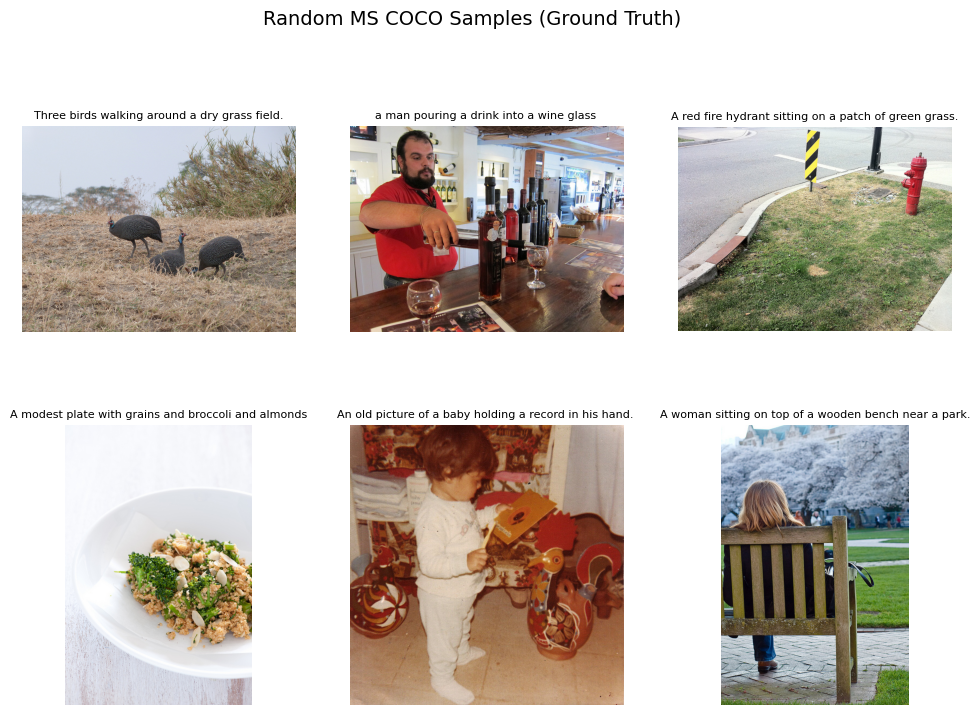

In [28]:
import matplotlib.pyplot as plt
import random

# ============================================================
# Visualize random dataset samples (Ground Truth Captions)
# ============================================================
def visualize_samples(image_paths, captions, n=6):
    plt.figure(figsize=(12, 8))
    for i, idx in enumerate(random.sample(range(len(image_paths)), n)):
        img = Image.open(image_paths[idx]).convert('RGB')
        plt.subplot(2, n//2, i+1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(captions[idx], fontsize=8)
    plt.suptitle("Random MS COCO Samples (Ground Truth)", fontsize=14)
    plt.show()

# Show GT captions before training
visualize_samples(image_paths, captions, n=6)


In [29]:

# ============================================================
# 9. CNN Encoder + Transformer Decoder Model
# ============================================================
class CNN_TransformerCaptioner(nn.Module):
    def __init__(self, embed_size, vocab_size, num_heads, num_layers, dropout=0.1, max_len=25):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        modules = list(resnet.children())[:-1]
        self.cnn = nn.Sequential(*modules)
        for p in self.cnn.parameters():
            p.requires_grad = False
        self.linear = nn.Linear(resnet.fc.in_features, embed_size)

        self.pos_encoding = nn.Parameter(torch.zeros(max_len, embed_size))

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=embed_size, nhead=num_heads, dropout=dropout, batch_first=True
        )
        self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)

        self.embed = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.fc = nn.Linear(embed_size, vocab_size)
        self.max_len = max_len

    def forward(self, images, captions):
        img_feat = self.cnn(images).squeeze(-1).squeeze(-1)  # [B,2048]
        img_feat = self.linear(img_feat).unsqueeze(1)        # [B,1,embed]

        cap_embed = self.embed(captions)                     # [B,seq,embed]
        seq_len = cap_embed.size(1) + 1
        pos = self.pos_encoding[:seq_len, :].unsqueeze(0)    # [1,seq_len,embed]

        memory = img_feat + pos[:, 0:1, :]
        tgt = cap_embed + pos[:, 1:seq_len, :]

        tgt_mask = nn.Transformer.generate_square_subsequent_mask(seq_len-1).to(captions.device)
        out = self.transformer_decoder(tgt, memory, tgt_mask=tgt_mask)
        out = self.fc(out)
        return out



In [30]:
# ============================================================
# Check model with dummy data
# ============================================================
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = CNN_TransformerCaptioner(
    embed_size=256, vocab_size=len(tokenizer.itos),
    num_heads=4, num_layers=3, dropout=0.1, max_len=35
).to(device)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
dummy_images = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)
# Dummy captions with a sequence length of 10
dummy_captions = torch.randint(0, len(tokenizer.itos), (2, 10)).to(device)

try:
    with torch.no_grad():
        dummy_output = model(dummy_images, dummy_captions)
    print("Model output shape:", dummy_output.shape)
except Exception as e:
    print("Error during dummy data test:", e)

Model output shape: torch.Size([2, 10, 3423])


In [31]:
# ============================================================
# 10. Training
# ============================================================
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = CNN_TransformerCaptioner(
    embed_size=256, vocab_size=len(tokenizer.itos),
    num_heads=4, num_layers=3, dropout=0.1, max_len=45
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
best_loss = float('inf')
model_path = "/content/drive/MyDrive/upload/best_cnn_transformer_captioner.pth"

for epoch in range(20):
    model.train()
    total_loss = 0
    for imgs, cap_in, cap_out in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        imgs, cap_in, cap_out = imgs.to(device), cap_in.to(device), cap_out.to(device)
        preds = model(imgs, cap_in)  # [B, seq, vocab]
        loss = criterion(preds.reshape(-1, preds.size(-1)), cap_out.reshape(-1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    val_loss = 0
    model.eval()
    with torch.no_grad():
        for imgs, cap_in, cap_out in val_loader:
            imgs, cap_in, cap_out = imgs.to(device), cap_in.to(device), cap_out.to(device)
            preds = model(imgs, cap_in)
            loss = criterion(preds.reshape(-1, preds.size(-1)), cap_out.reshape(-1))
            val_loss += loss.item()
    print(f"Train Loss: {total_loss/len(train_loader):.4f}, Val Loss: {val_loss/len(val_loader):.4f}")
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), model_path)
        print("Saved best model.")




Epoch 1:   0%|          | 0/67 [00:00<?, ?it/s]

Train Loss: 5.8893, Val Loss: 5.0518
Saved best model.


Epoch 2:   0%|          | 0/67 [00:00<?, ?it/s]

Train Loss: 4.6845, Val Loss: 4.4623
Saved best model.


Epoch 3:   0%|          | 0/67 [00:00<?, ?it/s]

...

Train Loss: 2.3261, Val Loss: 3.2693
Saved best model.


Epoch 19:   0%|          | 0/67 [00:00<?, ?it/s]

Train Loss: 2.2620, Val Loss: 3.2668
Saved best model.


Epoch 20:   0%|          | 0/67 [00:00<?, ?it/s]

Train Loss: 2.1911, Val Loss: 3.2658
Saved best model.


In [32]:
# ============================================================
# 11. Load model for inference
# ============================================================
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()


CNN_TransformerCaptioner(
  (cnn): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0)

In [33]:

# ============================================================
# 12. Caption generation (Greedy decoding)
# ============================================================
def predict_caption(image_pil):
    model.eval()
    image = transform(image_pil).unsqueeze(0).to(device)
    img_feat = model.cnn(image).squeeze(-1).squeeze(-1)
    img_feat = model.linear(img_feat).unsqueeze(1)

    seq = [tokenizer.stoi['<start>']]
    for _ in range(25):
        cap_in = torch.tensor(seq).unsqueeze(0).to(device)
        cap_embed = model.embed(cap_in)
        seq_len = cap_embed.size(1) + 1
        pos = model.pos_encoding[:seq_len, :].unsqueeze(0)
        memory = img_feat + pos[:, 0:1, :]
        tgt = cap_embed + pos[:, 1:seq_len, :]
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(seq_len-1).to(device)
        out = model.transformer_decoder(tgt, memory, tgt_mask=tgt_mask)
        logits = model.fc(out)
        next_id = logits[0, -1].argmax().item()
        seq.append(next_id)
        if next_id == tokenizer.stoi['<end>']:
            break
    return image_pil, tokenizer.decode(seq)


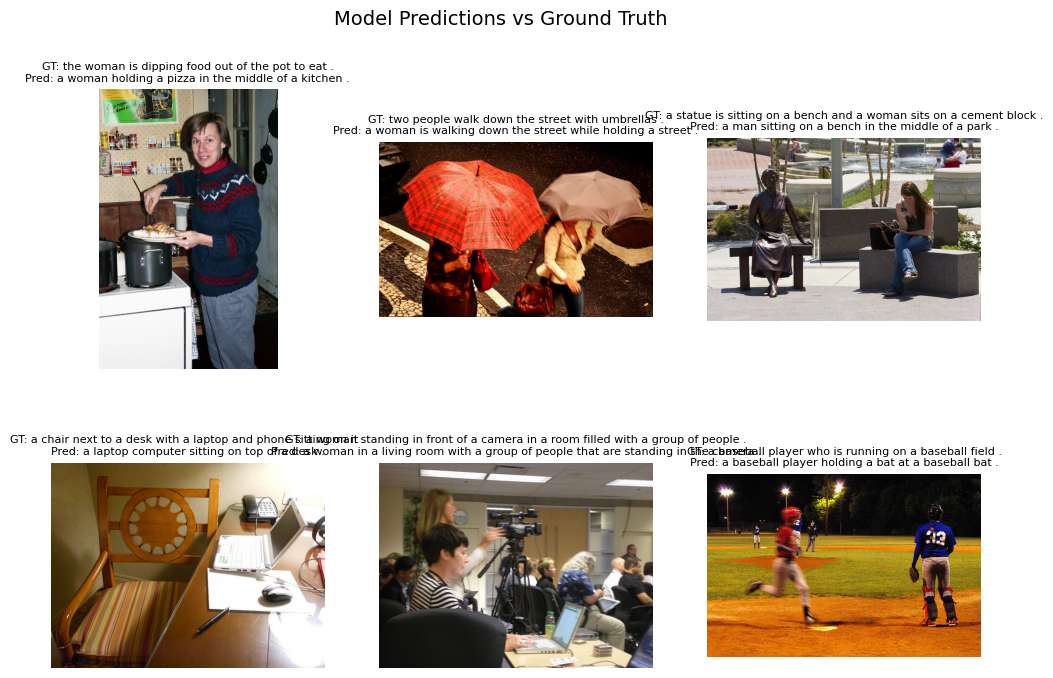

In [35]:
# ============================================================
# Visualize predictions vs ground truth
# ============================================================
def visualize_predictions(model, image_paths, captions, tokenizer, n=6):
    model.eval()
    plt.figure(figsize=(12, 8))
    # Sample directly from the original image_paths and captions
    sampled_indices = random.sample(range(len(image_paths)), n)
    for i, idx in enumerate(sampled_indices):
        original_img_path = image_paths[idx]
        original_img = Image.open(original_img_path).convert('RGB')

        # Get the corresponding ground truth caption
        gt_caption = captions[idx]
        # Use the original image for prediction
        pred_img, pred_caption = predict_caption(original_img)

        plt.subplot(2, n//2, i+1)
        plt.imshow(original_img) # Display the original image
        plt.axis('off')
        # Decode the ground truth caption from the tokenizer's perspective for consistent display
        # Note: This assumes the captions list contains the raw strings. If it contains tokenized IDs,
        # you would decode from those instead. Based on the notebook, it contains strings.
        gt_caption_decoded = tokenizer.decode(tokenizer.encode(gt_caption))

        plt.title(f"GT: {gt_caption_decoded}\nPred: {pred_caption}", fontsize=8)
    plt.suptitle("Model Predictions vs Ground Truth", fontsize=14)
    plt.show()

# Show model predictions after training, passing original lists
visualize_predictions(model, image_paths, captions, tokenizer, n=6)

In [36]:
# ============================================================
# 13. Gradio interface
# ============================================================
iface = gr.Interface(
    fn=predict_caption,
    inputs=gr.Image(type="pil", label="Upload an Image"),
    outputs=[gr.Image(type="pil"), gr.Textbox(label="Generated Caption")],
    title="Image Captioning (PyTorch CNN+Transformer Decoder)",
    description="Upload an image and generate a caption from a CNN+Transformer model trained on MS COCO 10k.",
)
iface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://32c6e81807f02205cf.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [39]:
torch.save(model.state_dict(), "/content/drive/MyDrive/upload/best_cnn_transformer_captioner.pth")

In [40]:
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()


CNN_TransformerCaptioner(
  (cnn): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0)